# Machine Learning Pipeline

Now that we have experience preparing data for input to machine learning libraries, the next step will be to train, tune, and test a model.  You will perform all three of these steps in this hands-on activity.

The assignment consists of the following steps:

1. Load two datasets and prepare their representations and labels for model input. 
2. Split the data into training and testing.
3. Select a model, and identify the parameters to tune.
4. Tune the model.
5. Evaluate the model's performance.

In [9]:
import logging
logging.getLogger("scapy.runtime").setLevel(logging.ERROR)

from netml.pparser.parser import PCAP
from netml.utils.tool import dump_data, load_data

import pandas as pd

## Convert the Packet Capture Into Flows

1. Load the two packet captures for HTTP requests and Log4j scan, 
2. convert them into traffic flows, 
3. generate features from the flow,  
4. label the traffic,
5. normalize your labeled features into a 2D matrix

In [10]:
MINIMUM_PACKETS = 2

# HTTP requests -> benign traffic
http_pcap = PCAP('data/http.pcap', flow_ptks_thres=MINIMUM_PACKETS)
http_pcap.pcap2flows()
http_pcap.flow2features('STATS', fft=False, header=False)

# Log4j scan -> attack traffic
log4j_pcap = PCAP('data/log4j.pcap', flow_ptks_thres=MINIMUM_PACKETS)
log4j_pcap.pcap2flows()
log4j_pcap.flow2features('STATS', fft=False, header=False)

print(f"HTTP:  {len(http_pcap.flows)} flows, features {http_pcap.features.shape}")
print(f"Log4j: {len(log4j_pcap.flows)} flows, features {log4j_pcap.features.shape}")

HTTP:  291 flows, features (291, 12)
Log4j: 4795 flows, features (4795, 12)


In [11]:
import numpy as np

# Label the flows: 0 = normal (HTTP), 1 = attack (Log4j)
X_http, y_http = http_pcap.features, np.zeros(len(http_pcap.features))
X_log4j, y_log4j = log4j_pcap.features, np.ones(len(log4j_pcap.features))

print(f"HTTP:  X={X_http.shape}, y={y_http.shape}, labels={set(y_http)}")
print(f"Log4j: X={X_log4j.shape}, y={y_log4j.shape}, labels={set(y_log4j)}")

HTTP:  X=(291, 12), y=(291,), labels={np.float64(0.0)}
Log4j: X=(4795, 12), y=(4795,), labels={np.float64(1.0)}


In [12]:
# Combine into a single labeled 2D feature matrix
X = np.vstack([X_http, X_log4j])
y = np.concatenate([y_http, y_log4j])

print(f"X: {X.shape}, y: {y.shape}, labels={set(y)}")

X: (5086, 12), y: (5086,), labels={np.float64(0.0), np.float64(1.0)}


## Evaluating a Machine Learning Model

The goal of supervised learning is to train a model that takes examples and predicts labels for these examples that are as close as possible to the actual labels. For instance, in this example above, a model might take features from a traffic trace and predict whether the traffic constitutes regular web traffic or a scan.

How do you measure whether the model is succeeding if you don't know the true labels for new observations? The way to solve this problem is to test the performance of the trained algorithm on additional data that it has never seen, but for which you already know the correct labels. 

This requires that you train the algorithm using only a portion of the entire labeled dataset (the **training set**) and withold the rest of the labeled data (the **test set**) for testing how well the model generalizes to new information. 

To evaluate the model, we will need to split the data into train and test sets.

### Split into Training and Test Sets

Split your data into a training and test set using scikit-learn. A common split is to train on 80% of your data, while withholding 20% of the data. 

In [13]:
from sklearn.model_selection import train_test_split

# 80% train, 10% validation, 10% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (4068, 12), Val: (509, 12), Test: (509, 12)


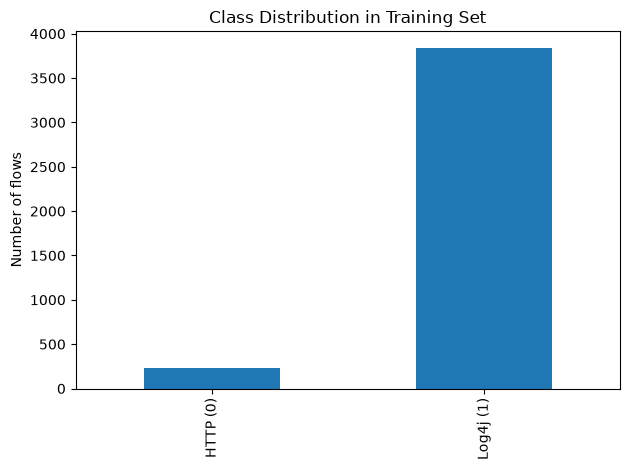

HTTP (train) stat characteristics:
                      mean           std         min           max
duration         11.628171  1.570884e+01    0.000030  4.507312e+01
pkts_rate       855.361890  5.390898e+03    0.104908  6.657625e+04
bytes_rate   241235.053172  1.169272e+06    8.056242  1.152523e+07
mean_size       351.459833  3.996907e+02   60.000000  1.495744e+03
std_size        237.416390  2.126068e+02    0.000000  7.206716e+02
q1_size         217.354077  4.243062e+02   60.000000  1.514000e+03
median_size     293.266094  4.730137e+02   60.000000  1.514000e+03
q3_size         453.903433  5.497440e+02   60.000000  1.514000e+03
min_size         67.446352  9.665879e+00   60.000000  1.390000e+02
max_size        772.334764  5.541195e+02   60.000000  1.514000e+03
num_pkts         91.420601  3.716365e+02    2.000000  2.985000e+03
num_bytes    110418.304721  5.440286e+05  132.000000  4.464796e+06

Log4j (train) stat characteristics:
                     mean            std        min      

In [14]:
import matplotlib.pyplot as plt

STATS_NAMES = ['duration', 'pkts_rate', 'bytes_rate', 'mean_size', 'std_size',
               'q1_size', 'median_size', 'q3_size', 'min_size', 'max_size',
               'num_pkts', 'num_bytes']

# Class distribution in the training set
counts = pd.Series(y_train).value_counts().sort_index()
counts.index = ['HTTP (0)', 'Log4j (1)']
counts.plot(kind='bar')
plt.ylabel('Number of flows')
plt.title('Class Distribution in Training Set')
plt.tight_layout()
plt.show()

# Per-stat characteristics (mean, std, min, max) for each class in the training set
train_df = pd.DataFrame(X_train, columns=STATS_NAMES)
train_df['label'] = y_train

http_stats = train_df[train_df['label'] == 0][STATS_NAMES].agg(['mean', 'std', 'min', 'max']).T
log4j_stats = train_df[train_df['label'] == 1][STATS_NAMES].agg(['mean', 'std', 'min', 'max']).T

print("HTTP (train) stat characteristics:")
print(http_stats)
print("\nLog4j (train) stat characteristics:")
print(log4j_stats)

In [15]:
from sklearn.preprocessing import StandardScaler

# Fit the scaler on the training set only, then apply it to val/test
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

### Training Your Model

Now that you have split your data into training and testing sets, you are ready to train and evaluate a model. 

Import a machine learning model of your choice, use your training set to train the model, and use the test set to evaluate it. 

In [16]:
from sklearn.ensemble import RandomForestClassifier

# class_weight reweights samples during tree splitting -- RF's analog of a
# weighted loss -- so the minority class (HTTP) isn't drowned out by the
# majority class (Log4j). 'balanced_subsample' recomputes weights on each
# bootstrap sample, which sklearn recommends specifically for RandomForestClassifier.
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced_subsample',
    random_state=42,
)
rf.fit(X_train, y_train)

print(f"Train accuracy: {rf.score(X_train, y_train):.4f}")
print(f"Val accuracy:   {rf.score(X_val, y_val):.4f}")

Train accuracy: 1.0000
Val accuracy:   0.9961


### Test Your Trained Model

You can now evaluate how well your trained model works.  There are several valuable ways to visualize your results. You might use techniques such as a confusion matrix, or a receiver operating characteristic (ROC) curve. Below we will gain some experience plotting both of those.  This [documentation](https://scikit-learn.org/stable/auto_examples/miscellaneous/plot_display_object_visualization.html) may help you with plotting these results.

#### Confusion Matrix 

A confusion matrix is a one way to understand errors of different types. We can see a lot of examples off diagonal, suggesting a fair number of incorrect answers.

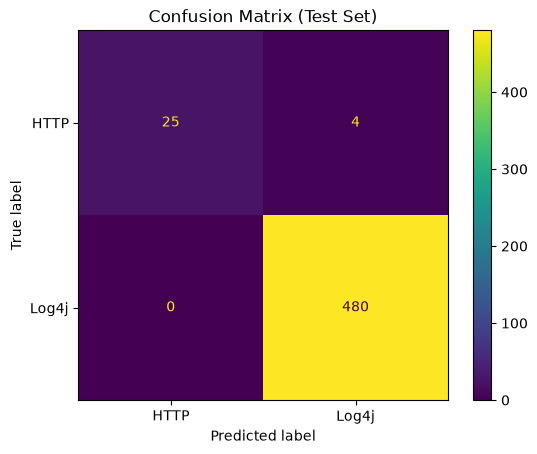

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, display_labels=['HTTP', 'Log4j'])
plt.title('Confusion Matrix (Test Set)')
plt.show()

#### Precision and Recall

Precision and recall break the confusion matrix into two rates: precision asks "of the flows we flagged as attacks, how many really were attacks?" and recall asks "of the actual attacks, how many did we catch?" These matter more than raw accuracy on an imbalanced dataset like this one.

In [18]:
from sklearn.metrics import precision_score, recall_score, classification_report

y_pred = rf.predict(X_test)

print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['HTTP', 'Log4j']))

Precision: 0.9917
Recall:    1.0000

              precision    recall  f1-score   support

        HTTP       1.00      0.86      0.93        29
       Log4j       0.99      1.00      1.00       480

    accuracy                           0.99       509
   macro avg       1.00      0.93      0.96       509
weighted avg       0.99      0.99      0.99       509



#### Precision-Recall Curve

Like the ROC curve below, this sweeps the decision threshold, but plots precision against recall instead of true/false positive rate. It's generally the more informative curve on imbalanced data -- note that in this dataset it's HTTP (label 0) that's the minority class, not Log4j.

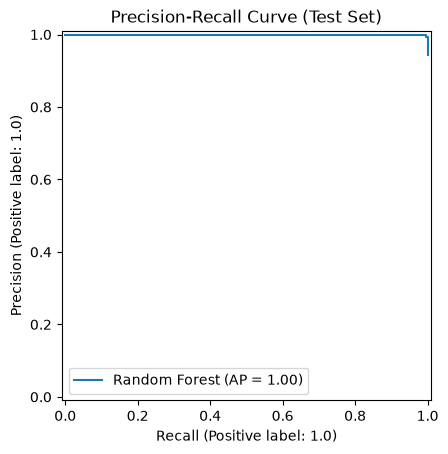

In [19]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(rf, X_test, y_test, name='Random Forest')
plt.title('Precision-Recall Curve (Test Set)')
plt.show()

#### Receiver Operating Characteristic

Some models can output different classes based on a threshold that is set for the decision. 

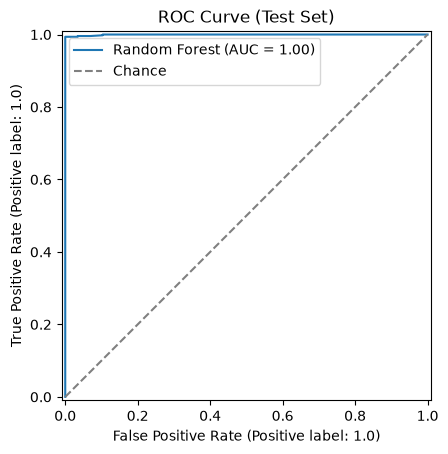

In [20]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(rf, X_test, y_test, name='Random Forest')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
plt.title('ROC Curve (Test Set)')
plt.legend()
plt.show()

#### Area Under the Curve (AUC)

From the ROC above, you can also compute a metric called the area under the curve (AUC). Visually, this is the area under the curve that you just plotted. You could see, intuitively, that the "best" performance should yield an AUC of 1, and the worst performance would yield an AUC closer to 0.5.

Scikit learn also has a function for computing AUC.  Compute the area under the curve.

In [21]:
from sklearn.metrics import roc_auc_score

y_proba = rf.predict_proba(X_test)[:, 1]
print(f"AUC: {roc_auc_score(y_test, y_proba):.4f}")

AUC: 0.9995


## Thought Question

Which evaluation model is more appropriate, and when (i.e., under what circumstances)? When might you care more about looking at the confusion matrix (or model accuracy) vs. the ROC, or the area under the curve?

Precision and recall are generally more appropriate when the number of true negatives is huge, but in this case it seems that log4j vs http is just trivially seperable based on the extremely good precision / recall curve and the very high AUC. 